<h1 align="center">Diamond Exploratory Data Analysis </h1>
<p align="center">
  <img src="https://img.shields.io/badge/Python-3.13+-blue.svg" alt="Python 3.13+">
  <img src="https://img.shields.io/badge/Pandas-Data%20Analysis-orange.svg" alt="Pandas">
  <img src="https://img.shields.io/badge/Seaborn-Visualization-green.svg" alt="Seaborn">
</p>

 **Objective**
- The primary objective of this project is to perform an exploratory data analysis (EDA) on the diamonds dataset, investigate the statistical distribution of various features (such as cut, color, and clarity), and determine whether there are statistically significant differences in diamond prices across different cut categories using analysis of variance (ANOVA) and post-hoc testing.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

data = sns.load_dataset('diamonds')
sns.set_style('whitegrid')

In [3]:
display(data.shape)
display(data.head())                     
display(data.info())
display(data.isnull().sum())


(53940, 10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


None

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

---

## Descriptive Statistics

Price Variable: The mean is significantly higher than the median, indicating a small number of very expensive (luxury) diamonds that pull the average upward. Looking at the minimum ($326) and maximum ($18,823) values, it is clear that there is a wide range of high-end diamonds in the dataset.

Dimension Variables (x, y, z): The presence of 0 values in the dimensions suggests measurement errors or faulty records.

Table Variable: When examining the diamond's table (width of the top flat surface), the mean is 57.4.

Carat Variable: The mean is 0.79, with a maximum of 5.0 and a minimum of 0.2. The large gap between the min and max values indicates high variance, outliers, a non-homogeneous distribution, and a notable deviation from a normal distribution.

In [4]:
display(data.describe())

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


---

## Cut

- The Ideal cut is the most dominant category, followed by Premium, Very Good, and Good. The Fair category has the lowest number of observations. Premium and Very Good cuts are relatively close in frequency, indicating an imbalance across categories.

- Price variation tends to decrease from left to right across cut quality.

## Color

- The color grades represent how colorless the diamond is, becoming slightly yellow as you move from D to J.

- Colorless (D, E, F): D is completely colorless, while E and F may have subtle traces detectable by experts. They have a combined frequency between 6,000 and 10,000 observations.

- Near-Colorless (G, H, I): These are colorless to the naked eye. The G category alone has over 10,000 observations.

- Faint Yellow (J): The least frequent group, with fewer than 4,000 observations.

## Clarity 

- Measures the purity and internal characteristics (inclusions) of the diamonds.

- IF is the most flawless grade, while VVS1 and VVS2 have tiny inclusions detectable under magnification.

- Grades such as VS1, VS2, SI1, and SI2 have minor inclusions that can be seen under 10x magnification.

- I1 represents the lowest grade with obvious inclusions visible to the naked eye.

- Prices decrease as you move towards lower clarity grades. The dataset is dominated by medium-clarity diamonds, with fewer observations at the extreme high (IF) and low (I1) ends.

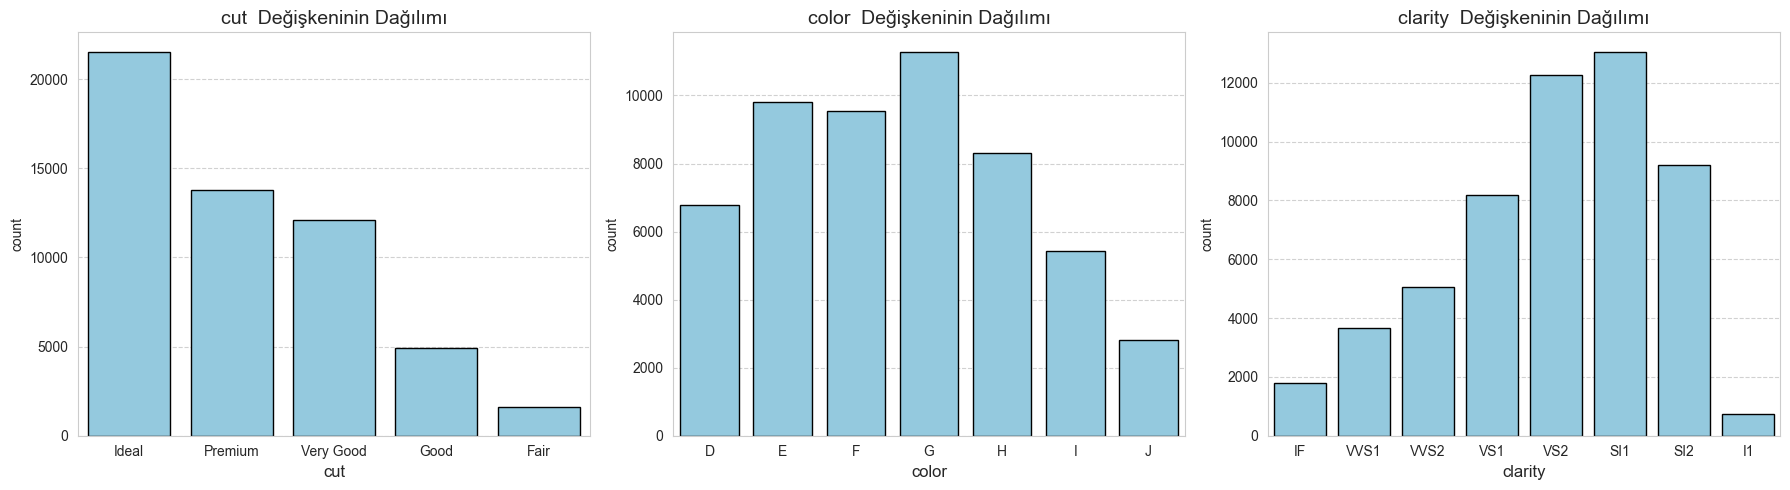

In [5]:
cat_col = ['cut', 'color', 'clarity']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


for i, col in enumerate(cat_col):
    sns.countplot(
        x=data[col],
        ax=axes[i],
        zorder=2,
        color='skyblue',
        edgecolor='black'
    )

    axes[i].grid(
        axis='y',
        linestyle='--',
        alpha=0.9
        )
    
    axes[i].set_title(f'{col}  Değişkeninin Dağılımı', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
     
plt.tight_layout()
plt.show()

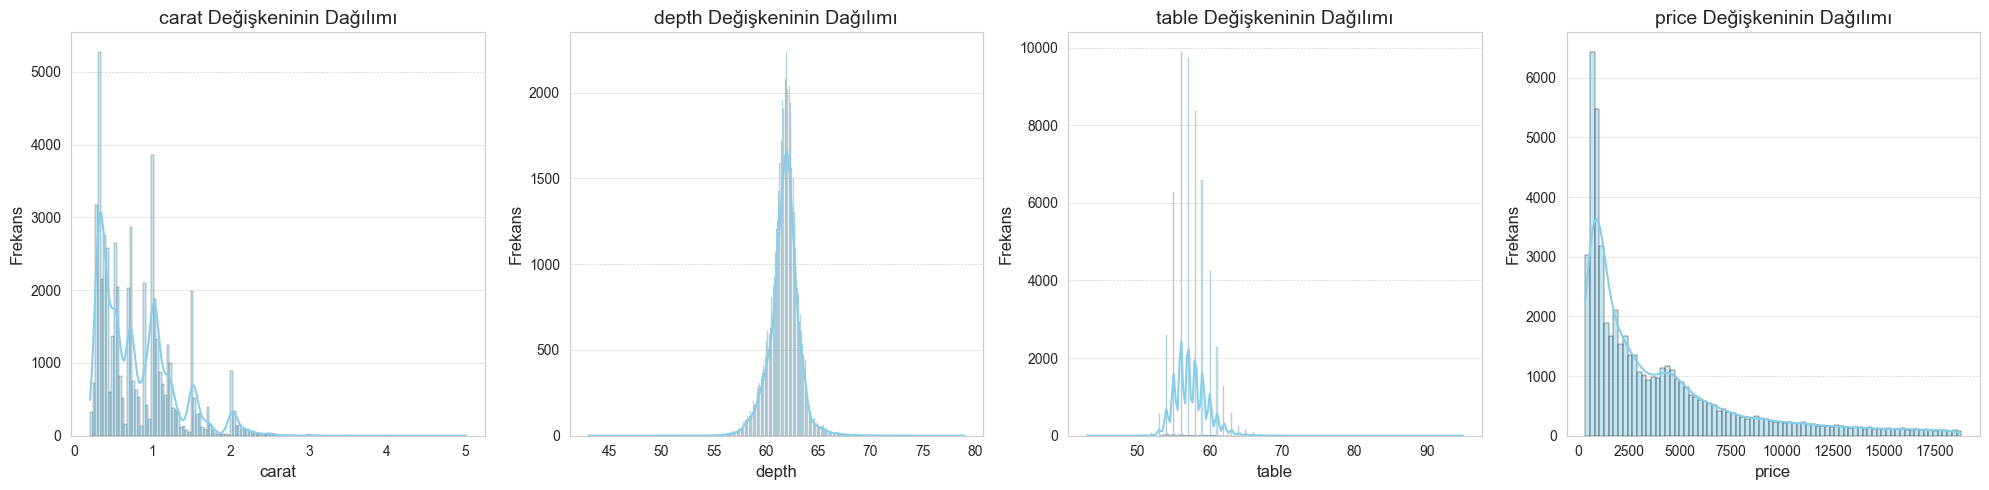

In [6]:
num_col = ['carat', 'depth', 'table', 'price']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()
ax = plt.gca()

for i, col in enumerate(num_col):
    sns.histplot(
        x=data[col],
        color='skyblue',
        edgecolor='black',
        ax=axes[i], 
        kde=True
    )

    axes[i].grid(
        axis='y',
        linestyle='--',
        linewidth=0.5,
        alpha=0.9
     )
    axes[i].grid(False, axis='x')

    axes[i].set_title(f'{col} Değişkeninin Dağılımı', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frekans', fontsize=12)
    
plt.tight_layout()
plt.show()

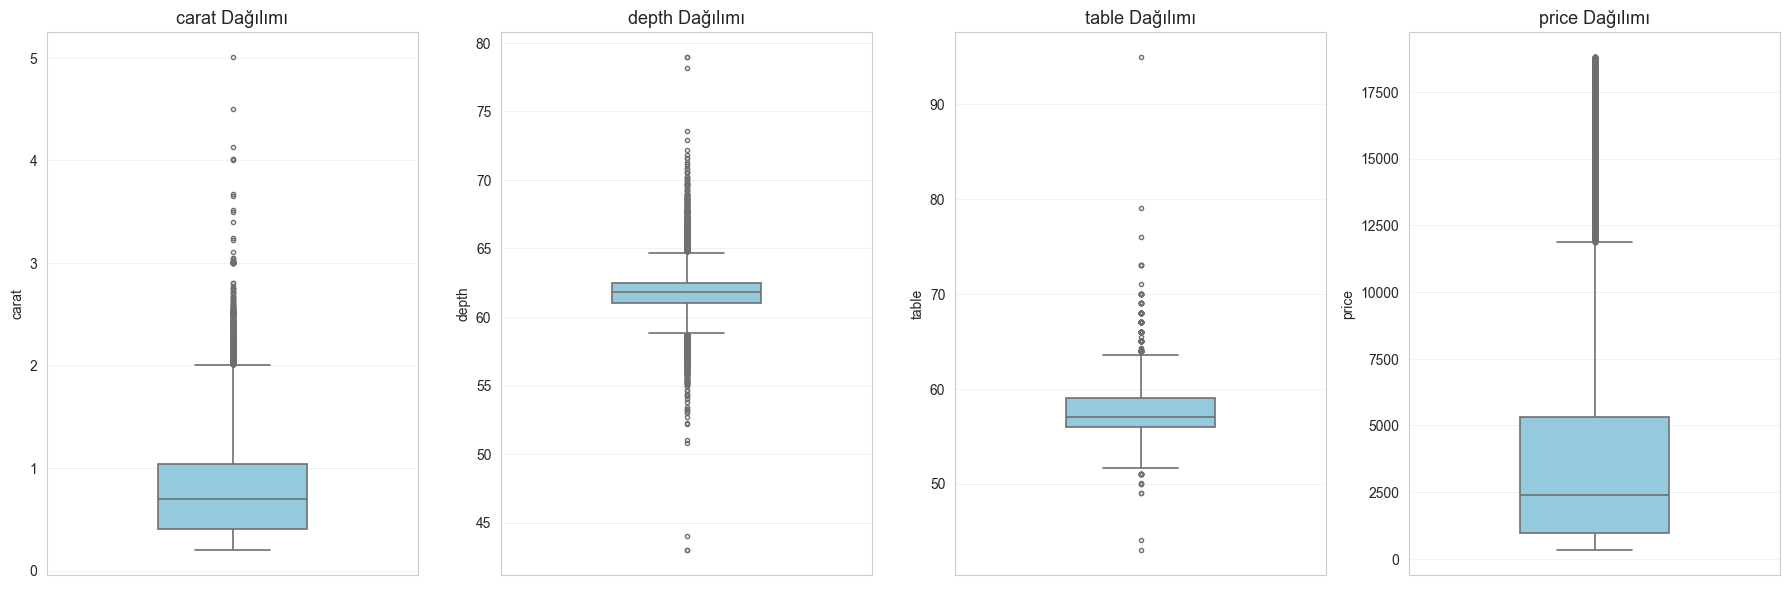

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes = axes.flatten()


for i, col in enumerate(num_col):
    sns.boxplot(
        data=data,
        y=col,
        ax=axes[i],
        color="skyblue",
        width=0.4,
        linewidth=1.2,
        fliersize=3
    )

    
    axes[i].grid(
        axis='y',
        linestyle='-',
        linewidth=0.6,
        alpha=0.5,
        color='#E0E0E0'
    )

    axes[i].set_title(f'{col} Dağılımı', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

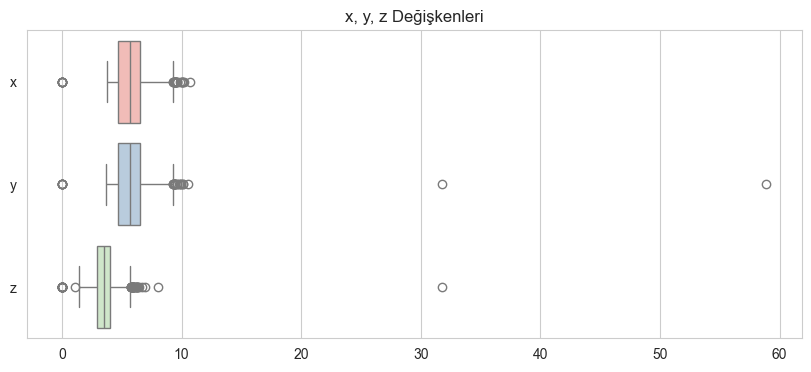

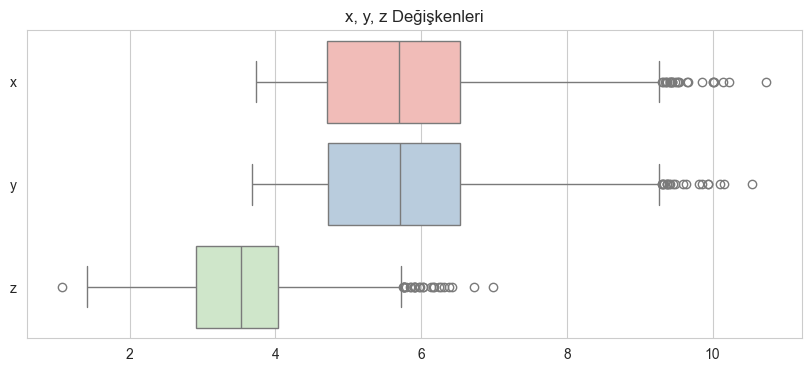

In [8]:
def boxplot_before_after(data):
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=data[['x', 'y', 'z']], orient='h', palette='Pastel1')    
    plt.title("x, y, z Değişkenleri")
    plt.show()
    
boxplot_before_after(data)

original_len = len(data)
data = data[
    (data[['x', 'y', 'z']] != 0).all(axis=1) &   
    (data['y'] < 30) &                           
    (data['z'] < 30)                             
]

boxplot_before_after(data)


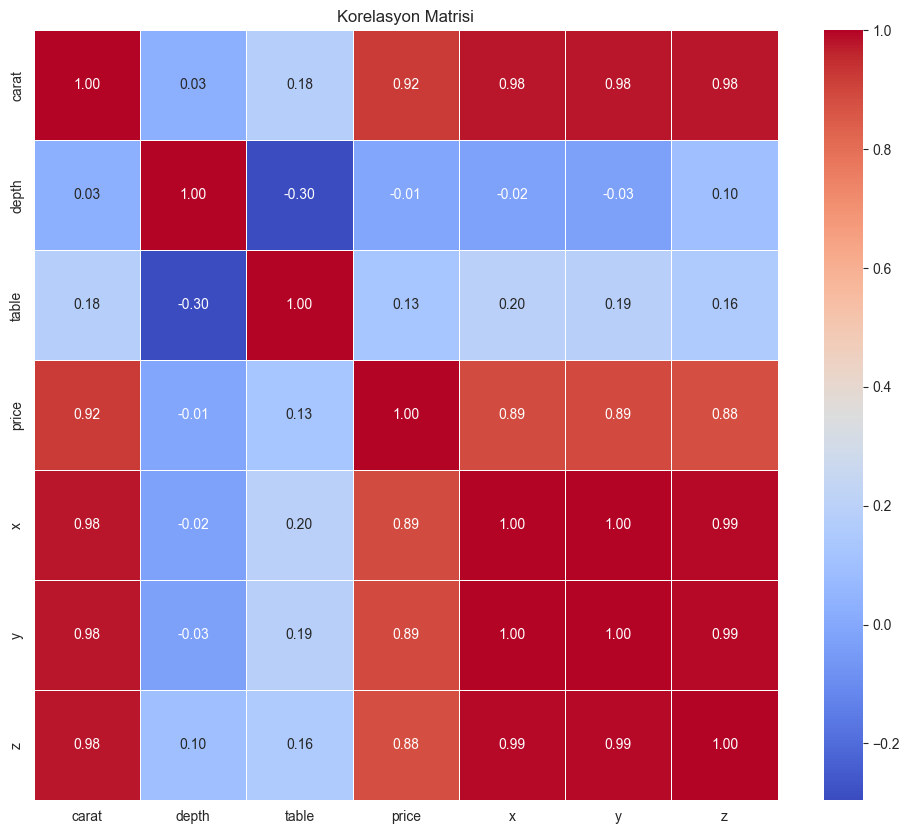

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Korelasyon Matrisi")
plt.show()

## Creating a New Variable (Volume)

In [10]:
data['volume'] = data['x'] * data['y'] * data['z']
data = data.drop(['x', 'y', 'z'], axis=1)
data['volume'] = data['volume'].round(2)
data.head()

,carat,cut,color,clarity,depth,table,price,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,38.20
1,0.21,Premium,E,SI1,59.8,61.0,326,34.51
2,0.23,Good,E,VS1,56.9,65.0,327,38.08
3,0.29,Premium,I,VS2,62.4,58.0,334,46.72
4,0.31,Good,J,SI2,63.3,58.0,335,51.92


--- 

## Null and Alternative Hypotheses:

- $H_0$:There is no statistically significant difference between the price means of the compared groups.
- $H_1$: There is a statistically  significant difference between the price means of the compared groups (i.e., at least one group's mean is different from the others).

In [12]:
groups = [group['price'].values for name, group in data.groupby('cut')]

f_stat, p_value = stats.f_oneway(*groups)

Anova = pd.DataFrame({'Değer': [f_stat, p_value]}, index=['F-İstatistiği', 'P-Değeri']).round(0)
Anova

,Değer
F-İstatistiği,174.0
P-Değeri,0.0


- F-Statistic: Calculated as the ratio of between-group variance to within-group variance.
- Decision: Since the p-value is less than 0.05, the null hypothesis ($H_0$) is rejected. This indicates that there is a statistically significant difference in mean prices among the groups.

---

In [13]:
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

data_encoded = data.copy()
data_encoded['cut_encoded'] = data_encoded['cut'].map(cut_map)
data_encoded['color_encoded'] = data_encoded['color'].map(color_map)
data_encoded['clarity_encoded'] = data_encoded['clarity'].map(clarity_map)

Unmapped counts (should be 0): {'cut': np.int64(0), 'color': np.int64(0), 'clarity': np.int64(0)}


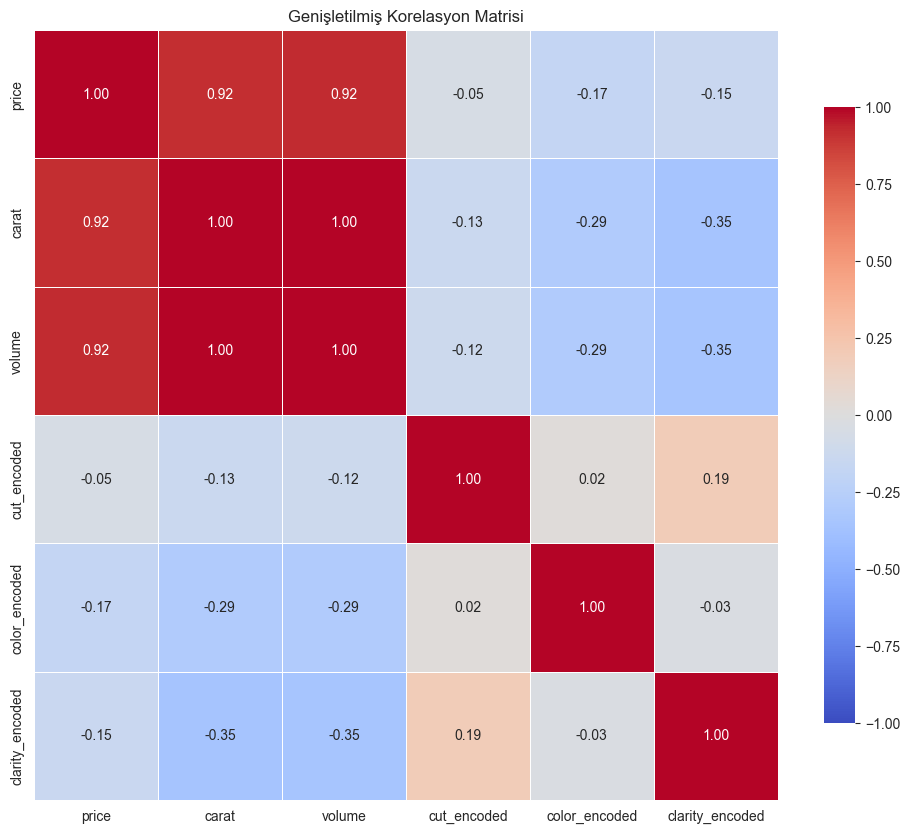

In [14]:
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

data_encoded = data.copy()
for col, mapping in [('cut', cut_map), ('color', color_map), ('clarity', clarity_map)]:
    data_encoded[f'{col}_encoded'] = data_encoded[col].map(mapping)
 
unmapped = {col: data_encoded[f'{col}_encoded'].isna().sum() for col in ['cut','color','clarity']}
print('Unmapped counts (should be 0):', unmapped)
 
data_encoded[['cut_encoded','color_encoded','clarity_encoded']] = data_encoded[['cut_encoded','color_encoded','clarity_encoded']].astype(float)
 
numeric_cols = data_encoded.select_dtypes(include=[np.number])
cols_focus = [c for c in ['price','carat','volume','cut_encoded','color_encoded','clarity_encoded'] if c in numeric_cols.columns]
if len(cols_focus) == 0:
    cols_focus = numeric_cols.columns.tolist()
corr_df = numeric_cols[cols_focus].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, cbar_kws={'shrink': .8}, vmin=-1, vmax=1)
plt.title("Genişletilmiş Korelasyon Matrisi")
plt.show()

---

## Tukey Multiple Comparison Test

- **Purpose of the Tukey Test:** The Tukey HSD (Honestly Significant Difference) test is conducted after an ANOVA test reveals significant differences between group means. It is used to determine exactly which specific groups differ from each other. In this analysis, it helps us understand which diamond cut categories (cut) are the source of the significant differences in price (price).

In [15]:
tukey = pairwise_tukeyhsd(endog=data['price'], groups=data['cut'], alpha=0.05)
display(tukey.summary())

group1,group2,meandiff,p-adj,lower,upper,reject
Fair,Good,-431.0974,0.0014,-741.6073,-120.5876,True
Fair,Ideal,-900.4956,0.0,-1179.7992,-621.192,True
Fair,Premium,221.6298,0.21,-63.0918,506.3514,False
Fair,Very Good,-375.6703,0.0033,-662.4778,-88.8628,True
Good,Ideal,-469.3982,0.0,-640.4158,-298.3806,True
Good,Premium,652.7273,0.0,472.9972,832.4573,True
Good,Very Good,55.4271,0.9226,-127.5895,238.4437,False
Ideal,Premium,1122.1254,0.0,1004.2397,1240.0112,True
Ideal,Very Good,524.8253,0.0,401.9871,647.6635,True
Premium,Very Good,-597.3001,0.0,-732.0039,-462.5964,True


- **Group Comparison Columns (group1, group2):** Indicate the specific pairs being compared in the test.
- **meandiff:** Represents the difference between the mean prices of the two groups. For instance, the first row shows a value of -431, meaning there is a difference of 431 units between the prices of "Fair" cut and "Good" cut diamonds.
- **p-adj:** The adjusted p-value is the most critical metric. It explains whether the observed difference is statistically significant or occurred merely by chance.
- **reject:** Indicates whether the null hypothesis ($H_0$) should be rejected. We observe that the null hypothesis is rejected for most pairs, except for a few. Upon inspecting the p-values for those non-rejected pairs, we see that they are quite high.

---

**Conclusion and Decision**
- Based on the statistical analysis, there are significant differences in the average prices across different diamond cut categories. The post-hoc Tukey HSD test confirms which specific categories differ.

Thank you for reading and reviewing this notebook!